## EXERCÍCIO PRÁTICO 

Semana `05`- Aula `02`

In [2]:
## Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.

import pandas as pd  # <--- Essa linha faltou!

URL = "https://github.com/cfneves/turma-visualizacao-de-dados/raw/refs/heads/master/alunos/anaysa_lopes/semana_04/bases/base_rh.xlsx"
df = pd.read_excel(URL)

df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

df["Ano_Admissao"] = df["Data_Admissao"].dt.year

In [3]:
## 2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.

contagem_cargo = df.groupby(["Departamento", "Cargo"]).size().reset_index(name="Total_Funcionarios")
print(contagem_cargo.head(10))

  Departamento        Cargo  Total_Funcionarios
0   Financeiro     Analista                  40
1   Financeiro   Assistente                  30
2   Financeiro  Coordenador                  37
3   Financeiro      Gerente                  44
4   Financeiro      Técnico                  38
5    Logística     Analista                  29
6    Logística   Assistente                  38
7    Logística  Coordenador                  38
8    Logística      Gerente                  33
9    Logística      Técnico                  18


In [18]:
## 3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.

admissoes_por_ano = df.groupby("Ano_Admissao").size().reset_index(name="Total_Admissoes")

admissoes_filtradas = admissoes_por_ano.query("Ano_Admissao >= 2020 and Ano_Admissao <= 2024")

print("--- 3. Admissões Filtradas (2020 - 2024) ---")
print(admissoes_filtradas)



--- 3. Admissões Filtradas (2020 - 2024) ---
   Ano_Admissao  Total_Admissoes
5          2020               94
6          2021               94
7          2022              108
8          2023              106
9          2024              113


In [20]:
## 4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.

headcount_depto = df.groupby("Departamento").size().reset_index(name="Total_Atual")

metas_df = pd.DataFrame({
    "Departamento": ["Financeiro", "Logística", "Manutenção", "Produção", "RH", "TI", "Vendas"],
    "Meta": [135, 130, 125, 185, 165, 135, 125]
})

df_final = pd.merge(headcount_depto, metas_df, on="Departamento", how="left")
df_final["Meta_Atingida"] = df_final["Total_Atual"] >= df_final["Meta"]

print("--- 4. Análise de Metas de Headcount ---")
print(df_final)

--- 4. Análise de Metas de Headcount ---
  Departamento  Total_Atual  Meta  Meta_Atingida
0   Financeiro          189   135           True
1    Logística          156   130           True
2     Produção          182   185          False
3           RH          166   165           True
4           TI          147   135           True
5       Vendas          160   125           True


In [11]:
## 5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.

pivot_genero = df.pivot_table(values="Salario", index="Departamento", columns="Genero", aggfunc="mean")

pivot_genero["Diferenca_F_M"] = (pivot_genero["F"] - pivot_genero["M"]).round(2)

print("--- 5. Tabela Dinâmica de Salários por Gênero ---")
print(pivot_genero)

--- 5. Tabela Dinâmica de Salários por Gênero ---
Genero                  F            M  Diferenca_F_M
Departamento                                         
Financeiro    8467.258571  8208.561939         258.70
Logística     8843.485258  8944.411864        -100.93
Produção      8797.639529  9118.663711        -321.02
RH            9009.201250  8546.056410         463.14
TI            8107.010139  8177.382267         -70.37
Vendas        8926.643896  7751.590120        1175.05


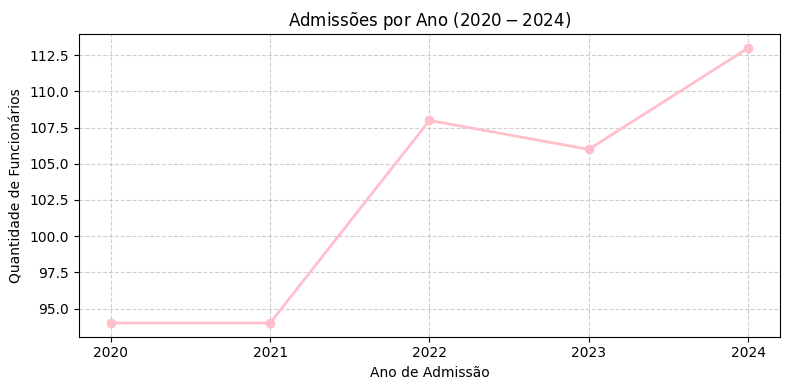

In [21]:
## 6. Plote admissões por ano com `plt.plot(..., marker="o")`.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(admissoes_filtradas["Ano_Admissao"], admissoes_filtradas["Total_Admissoes"], marker="o", color="pink", linewidth=2)
plt.title("Admissões por Ano ($2020 - 2024$)")
plt.xlabel("Ano de Admissão")
plt.ylabel("Quantidade de Funcionários")
plt.xticks(admissoes_filtradas["Ano_Admissao"]) 
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

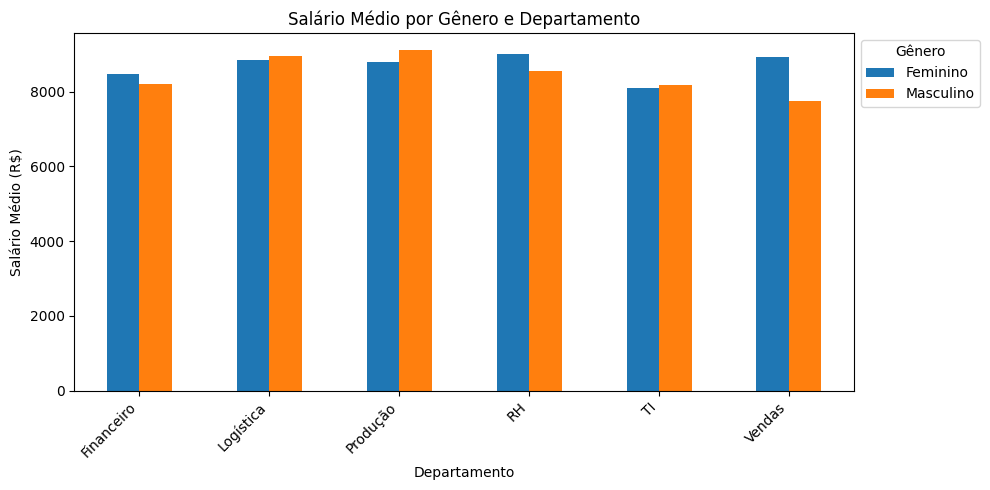

In [22]:
## 7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.

pivot_genero[["F", "M"]].plot(kind="bar", figsize=(10, 5))
plt.title("Salário Médio por Gênero e Departamento")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Gênero", labels=["Feminino", "Masculino"], bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()